<a href="https://colab.research.google.com/github/bautiunzue/produccion_bovina/blob/main/UTN_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/produccion-de-carne-bovina.csv', encoding='latin-1')

df.head()

,pais_id,pais,provincia_id,provincia,departamento_id,departamento,prov_depto,año,mes,modelo,...,ingreso_neto_($/ha),gastos_directos_($/ha),costos_indirectos_($/ha),eficiencia_stock_(%),producción_(kg/ha),destete_(%),carga_(kg/ha),Unnamed: 21,Unnamed: 22,Unnamed: 23
0,32,Argentina,6,Buenos Aires,105,Bolivar,6105,2018,2,buenos aires centro-sudoeste,...,3497,1730,1797,35,117,69,336,NaN,NaN,NaN
1,32,Argentina,6,Buenos Aires,231,Daireaux,6231,2018,2,buenos aires centro-sudoeste,...,3497,1730,1797,35,117,69,336,NaN,NaN,NaN
2,32,Argentina,6,Buenos Aires,203,Coronel Suarez,6203,2018,2,buenos aires centro-sudoeste,...,3497,1730,1797,35,117,69,336,NaN,NaN,NaN
3,32,Argentina,14,Cordoba,42,General San Martin,14042,2018,2,centro cordoba sur,...,4589,2544,1909,36,157,65,436,NaN,NaN,NaN
4,32,Argentina,14,Cordoba,56,Juarez Celman,14056,2018,2,centro cordoba sur,...,4589,2544,1909,36,157,65,436,NaN,NaN,NaN


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2598 entries, 0 to 2597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pais_id                   2598 non-null   int64  
 1   pais                      2598 non-null   object 
 2   provincia_id              2598 non-null   int64  
 3   provincia                 2598 non-null   object 
 4   departamento_id           2598 non-null   int64  
 5   departamento              2598 non-null   object 
 6   prov_depto                2598 non-null   int64  
 7   año                       2598 non-null   int64  
 8   mes                       2598 non-null   int64  
 9   modelo                    2598 non-null   object 
 10  actividad                 2598 non-null   object 
 11  referencia                2598 non-null   object 
 12  margen_bruto_($/ha)       2598 non-null   int64  
 13  resultado_neto_($/ha)     2598 non-null   int64  
 14  ingreso_

In [24]:
df.isnull().sum()

,0
pais_id,0
pais,0
provincia_id,0
provincia,0
departamento_id,0
departamento,0
prov_depto,0
año,0
mes,0
modelo,0


In [25]:
df.dropna(inplace=True)

In [26]:
df = pd.read_csv('/content/produccion-de-carne-bovina.csv', encoding='latin-1')

df = df.iloc[:, :-3]

display(df.head())
df.info()

,pais_id,pais,provincia_id,provincia,departamento_id,departamento,prov_depto,año,mes,modelo,...,referencia,margen_bruto_($/ha),resultado_neto_($/ha),ingreso_neto_($/ha),gastos_directos_($/ha),costos_indirectos_($/ha),eficiencia_stock_(%),producción_(kg/ha),destete_(%),carga_(kg/ha)
0,32,Argentina,6,Buenos Aires,105,Bolivar,6105,2018,2,buenos aires centro-sudoeste,...,http://www.agroindustria.gob.ar/sitio/areas/bo...,1766,-31,3497,1730,1797,35,117,69,336
1,32,Argentina,6,Buenos Aires,231,Daireaux,6231,2018,2,buenos aires centro-sudoeste,...,http://www.agroindustria.gob.ar/sitio/areas/bo...,1766,-31,3497,1730,1797,35,117,69,336
2,32,Argentina,6,Buenos Aires,203,Coronel Suarez,6203,2018,2,buenos aires centro-sudoeste,...,http://www.agroindustria.gob.ar/sitio/areas/bo...,1766,-31,3497,1730,1797,35,117,69,336
3,32,Argentina,14,Cordoba,42,General San Martin,14042,2018,2,centro cordoba sur,...,http://www.agroindustria.gob.ar/sitio/areas/bo...,2045,136,4589,2544,1909,36,157,65,436
4,32,Argentina,14,Cordoba,56,Juarez Celman,14056,2018,2,centro cordoba sur,...,http://www.agroindustria.gob.ar/sitio/areas/bo...,2045,136,4589,2544,1909,36,157,65,436


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2598 entries, 0 to 2597
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   pais_id                   2598 non-null   int64 
 1   pais                      2598 non-null   object
 2   provincia_id              2598 non-null   int64 
 3   provincia                 2598 non-null   object
 4   departamento_id           2598 non-null   int64 
 5   departamento              2598 non-null   object
 6   prov_depto                2598 non-null   int64 
 7   año                       2598 non-null   int64 
 8   mes                       2598 non-null   int64 
 9   modelo                    2598 non-null   object
 10  actividad                 2598 non-null   object
 11  referencia                2598 non-null   object
 12  margen_bruto_($/ha)       2598 non-null   int64 
 13  resultado_neto_($/ha)     2598 non-null   int64 
 14  ingreso_neto_($/ha)     

In [27]:
df_limpio = df.duplicated().sum()
print(f'Cantidad de duplicados: {df_limpio}')

Cantidad de duplicados: 0


In [28]:
exclusion = ['pais_id', 'provincia_id', 'departamento_id', 'prov_depto', 'año', 'mes']

# Seleccionamos todas las columnas excepto las de la lista anterior
df_filtrado = df.drop(columns=exclusion, errors='ignore')

display(df_filtrado.describe().round(2))

,margen_bruto_($/ha),resultado_neto_($/ha),ingreso_neto_($/ha),gastos_directos_($/ha),costos_indirectos_($/ha),eficiencia_stock_(%),producción_(kg/ha),destete_(%),carga_(kg/ha)
count,2598.00,2598.00,2598.00,2598.00,2598.00,2598.00,2598.00,2598.00,2598.00
mean,1001.08,414.79,1585.56,584.46,586.32,32.76,78.71,-16573.92,209.24
std,725.41,532.00,1344.48,864.81,486.09,9.40,76.29,37264.29,134.13
min,-107.00,-1299.00,205.00,46.00,75.00,20.00,7.00,-99999.00,19.00
25%,477.00,119.00,664.00,137.00,241.00,27.00,28.00,60.00,101.00
50%,645.00,241.00,1013.00,228.00,401.00,31.00,46.00,60.00,182.00
75%,1400.00,750.00,2286.00,423.00,777.00,35.00,92.00,69.00,293.00
max,3148.00,1761.00,5980.00,4424.00,2522.00,59.00,284.00,78.00,492.00


In [29]:
# Cargamos los datos originales
df_limpio = pd.read_csv("/content/produccion-de-carne-bovina.csv", encoding="latin-1")
df_limpio = df_limpio.iloc[:, :-3]

# En lugar de eliminar las filas de invernada, reemplazamos el -99999 por NaN (nulo)
df_limpio["destete_(%)"] = df_limpio["destete_(%)"].replace(-99999, np.nan)

# 2. Los porcentajes válidos (eficiencia) lógicamente deben estar entre 0 y 100
df_limpio = df_limpio[(df_limpio["eficiencia_stock_(%)"] >= 0) & (df_limpio["eficiencia_stock_(%)"] <= 100)]

print(f"Filas antes: {len(df_limpio)} | Filas después del filtro lógico:" f" {len(df_limpio)}")

# Mostramos el describe de las variables numéricas con las pérdidas conservadas y sin errores
exclusion = ["pais_id","provincia_id","departamento_id","prov_depto","año","mes",]
display(df_limpio.drop(columns=exclusion, errors="ignore").describe().round(2))

Filas antes: 2598 | Filas después del filtro lógico: 2598


,margen_bruto_($/ha),resultado_neto_($/ha),ingreso_neto_($/ha),gastos_directos_($/ha),costos_indirectos_($/ha),eficiencia_stock_(%),producción_(kg/ha),destete_(%),carga_(kg/ha)
count,2598.00,2598.00,2598.00,2598.00,2598.00,2598.00,2598.00,2166.00,2598.00
mean,1001.08,414.79,1585.56,584.46,586.32,32.76,78.71,64.88,209.24
std,725.41,532.00,1344.48,864.81,486.09,9.40,76.29,5.89,134.13
min,-107.00,-1299.00,205.00,46.00,75.00,20.00,7.00,50.00,19.00
25%,477.00,119.00,664.00,137.00,241.00,27.00,28.00,60.00,101.00
50%,645.00,241.00,1013.00,228.00,401.00,31.00,46.00,65.00,182.00
75%,1400.00,750.00,2286.00,423.00,777.00,35.00,92.00,72.00,293.00
max,3148.00,1761.00,5980.00,4424.00,2522.00,59.00,284.00,78.00,492.00


###Distribución del Resultado Neto ($/ha)

Hallazgos clave:
- Sesgo y Concentración: La mayor parte de los registros se concentran en valores positivos bajos, principalmente en el rango de $0 a $500 / ha.

- Media: La línea punteada roja marca el promedio general, ubicado en $415 / ha.

- Valores Negativos (Pérdidas): A la izquierda del gráfico se observan barras que representan unidades productivas con margen negativo, llegando a valores mínimos de cerca de -$1.000 / ha.

- *Conclusion*: Aunque la mayoría de las unidades ganaderas son rentables, existe una dispersión importante y un número no menor de casos con resultados económicos desfavorables.

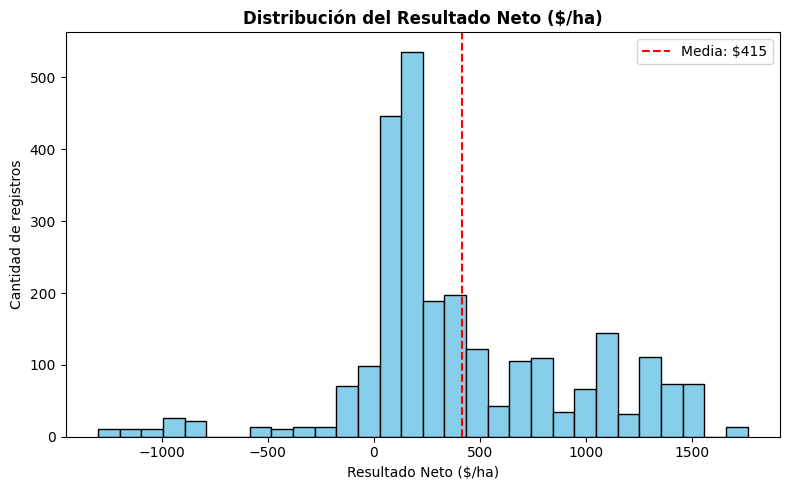

In [31]:
plt.figure(figsize=(8, 5))
plt.hist(
    df_limpio["resultado_neto_($/ha)"],
    bins=30,
    color="skyblue",
    edgecolor="black",
)
plt.title(
    "Distribución del Resultado Neto ($/ha)", fontweight="bold", fontsize=12
)
plt.xlabel("Resultado Neto ($/ha)", fontsize=10)
plt.ylabel("Cantidad de registros", fontsize=10)
plt.axvline(
    df_limpio["resultado_neto_($/ha)"].mean(),
    color="red",
    linestyle="--",
    label=f'Media: ${df_limpio["resultado_neto_($/ha)"].mean():.0f}',
)
plt.legend()
plt.tight_layout()
plt.show()

### Margen Bruto Promedio por Actividad ($/ha)

Hallazgos clave:
- Invernada ($1.296 / ha): Obtiene el mayor Margen Bruto medio, impulsada por su alto volumen de venta de carne por hectárea.

- Ciclo Completo ($1.176 / ha): Presenta un margen muy competitivo y cercano a la invernada, combinando la producción de terneros con el engorde.

- Cría ($895 / ha): Muestra el margen bruto por hectárea más bajo del sistema ganadero.

- *Conclusión*: En términos puramente operacionales (antes de restar costos indirectos de estructura), la invernada genera mayor flujo por hectárea que la cría.

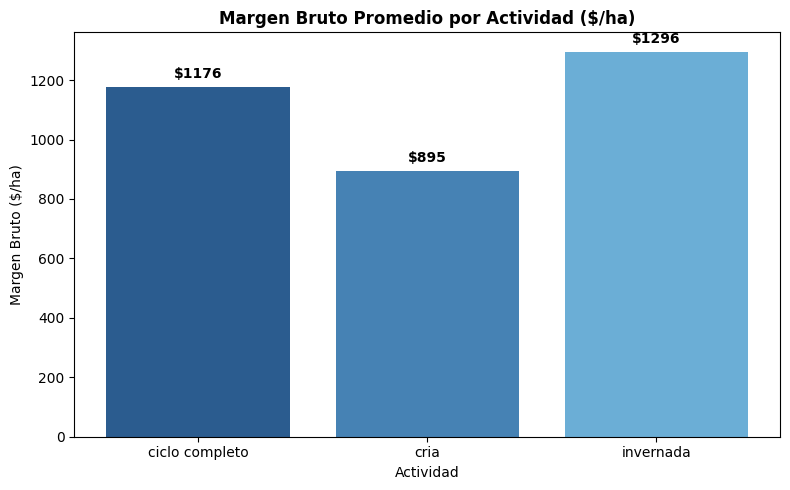

In [34]:
#Margen Bruto Promedio por Actividad ($/ha)

plt.figure(figsize=(8, 5))
margen_actividad = df_limpio.groupby("actividad")["margen_bruto_($/ha)"].mean()
bars = plt.bar(
    margen_actividad.index,
    margen_actividad.values,
    color=["#2b5c8f", "#4682b4", "#6baed6"],
)
plt.title(
    "Margen Bruto Promedio por Actividad ($/ha)",
    fontweight="bold",
    fontsize=12,
)
plt.xlabel("Actividad", fontsize=10)
plt.ylabel("Margen Bruto ($/ha)", fontsize=10)

for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      yval + 20,
      f"${yval:.0f}",
      ha="center",
      va="bottom",
      fontweight="bold",
  )

plt.tight_layout()
plt.show()

### Variabilidad de Producción (kg/ha) por Actividad

Hallazgos clave:
- Cría: Es la actividad más homogénea y compacta. Su producción mediana ronda los **30 - 45 kg/ha** y casi no presenta grandes variaciones entre establecimientos.

- Invernada: Presenta una caja extremadamente ancha y alta, alcanzando producciones de casi **280 kg/ha**. Muestra una gran disparidad entre planteles tradicionales y planteos de alta intensificación (feedlot/pasturas de alta calidad).

- Ciclo Completo: Exhibe una variabilidad intermedia, con producciones medianas alrededor de **65 - 90 kg/ha**.

- *Conclusión*: La invernada es una actividad heterogénea con amplio techo productivo, mientras que la cría tiene un tope biológico mucho más acotado por hectárea.

/tmp/ipykernel_561/1208788405.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


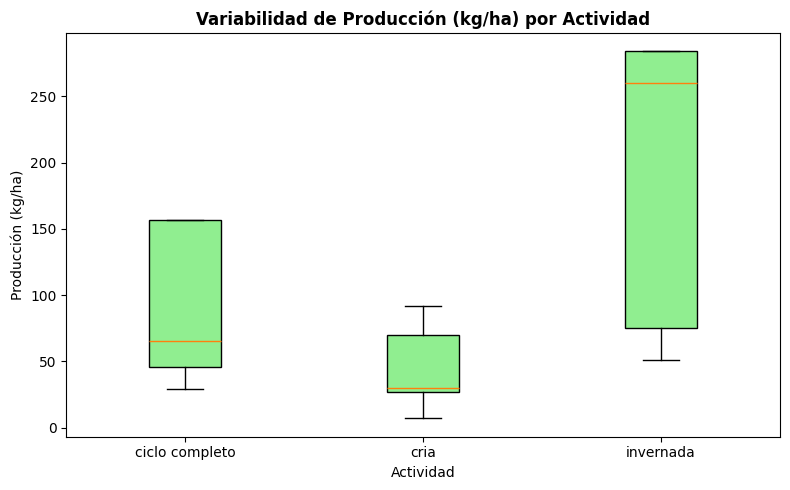

In [43]:
#Variabilidad de Producción (kg/ha) por Actividad

plt.figure(figsize=(8, 5))

actividades = df_limpio["actividad"].unique()
datos_prod = [
    df_limpio[df_limpio["actividad"] == act]["producción_(kg/ha)"].dropna()
    for act in actividades
]
plt.boxplot(
    datos_prod,
    labels=actividades,
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen"),
)
plt.title(
    "Variabilidad de Producción (kg/ha) por Actividad",
    fontweight="bold",
    fontsize=12,
)
plt.xlabel("Actividad", fontsize=10)
plt.ylabel("Producción (kg/ha)", fontsize=10)
plt.tight_layout()

plt.show()

### Relación entre Carga Animal (kg/ha) y Producción (kg/ha)

Hallazgos clave:
- Relación Lineal Positiva: Se observa un patrón claro en diagonal ascendente: a mayor carga animal por hectárea, mayor es la producción obtenida.

- Alta Correlación: Confirma la fuerte dependencia del rendimiento físico respecto a la capacidad de carga del establecimiento.

- *Conclusión:* Aumentar la receptividad o carga del campo (a través de mejor oferta forrajera o manejo de pastoreo) es la palanca directa principal para elevar los kg de carne producidos por hectárea.

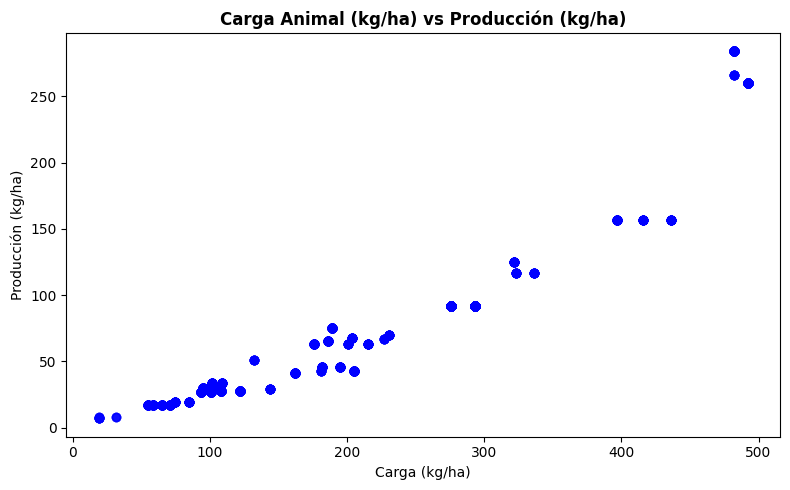

In [46]:
#Carga Animal (kg/ha) vs. Producción (kg/ha)

plt.figure(figsize=(8, 5))

plt.scatter(
    df_limpio["carga_(kg/ha)"],
    df_limpio["producción_(kg/ha)"],
    alpha=0.5,
    color="blue",
)
plt.title(
    "Carga Animal (kg/ha) vs Producción (kg/ha)",
    fontweight="bold",
    fontsize=12,
)
plt.xlabel("Carga (kg/ha)", fontsize=10)
plt.ylabel("Producción (kg/ha)", fontsize=10)
plt.tight_layout()

plt.show()